In [1]:
import joblib
import numpy as np
from pathlib import Path
from plotting import plot_sagd_heatmap_row_with_prob
from ou_model import find_third_phase_onset

In [ ]:
ds = [2, 50, 256, 1024, 16384]

exp_path = Path('../data/bimodal_gaussian_SAGD_log_scale_and_shift_clipped')

W_list = []
time_snaps_vector_list = []
sagd_dms = []
ts_list, tsagd_list, t_star_list = [], [], []
std = 1.0
mu = None
ctds_list = []

for d_i in ds:
    history = joblib.load(exp_path / f"D{d_i}_N1000_T10/history.jbl")
    breakpoints = joblib.load(exp_path / f"D{d_i}_N1000_T10/clusters.jbl")
    W_list.append(joblib.load(exp_path / f"D{d_i}_N1000_T10/Ws.jbl"))
    ctds = joblib.load(exp_path / f"D{d_i}_N1000_T10/CTDs.jbl")
    ctds_list.append(ctds)
    sagd_dms.append(joblib.load(exp_path / f"D{d_i}_N1000_T10/SAGD.jbl"))
    mu = history['params']['mu']
    snaps = history['params']['times_snapshots']
    ts_list.append(history['params']['ts_theoretical'])
    tsagd_list.append(snaps[breakpoints[0]])
    t_star_list.append(find_third_phase_onset(ctds['CTDs'], snaps))
    print({"Dim: {}, breakpoints: {}".format(d_i, breakpoints)})
    time_snaps_vector_list.append(snaps)
    
    

In [ ]:
plot_sagd_heatmap_row_with_prob(
    W_list=sagd_dms,
    d_list=ds,
    time_snaps_vector_list=time_snaps_vector_list,
    mu=mu,
    std=std,
    ts_list=ts_list,
    tsagd_list=tsagd_list,
    tstar_list=t_star_list,
    ctds_list=ctds_list,
    distance='SAGD',
    save_fig_path='sagd_hetmap_row_with_prob.png',
    show_prob=True
)

In [2]:
def plot_sagd_heatmap_row_mnist(exp_path, steps):
    subdirs = [exp_path / Path(exp_path.name + "_" + str(step)) for step in steps]

    W_list = []
    time_snaps_vector_list = []
    sagd_dms = []
    ts_list, tsagd_list, t_star_list = [], [], []
    std = 1.0
    mu = None
    ctds_list = []
    params = joblib.load(exp_path / "config.jbl")

    for subdir in subdirs:
        history = joblib.load(subdir / "history.jbl")
        snaps = np.asarray(list(history.keys()))
        time_snaps_vector_list.append(snaps)
        breakpoints = joblib.load(subdir / "clusters.jbl")
        W_list.append(joblib.load(subdir / "Ws.jbl"))
        ctds = joblib.load(subdir / "CTDs.jbl")
        ctds_list.append(ctds)
        sagd_dms.append(joblib.load(subdir / "SAGD.jbl"))
        ts_list.append(params['ts_theoretical'])
        tsagd_list.append(snaps[breakpoints[0]])
        t_star_list.append(find_third_phase_onset(ctds['CTDs'], snaps))

    plot_sagd_heatmap_row_with_prob(
        W_list=sagd_dms,
        d_list=steps,
        time_snaps_vector_list=time_snaps_vector_list,
        mu=mu,
        std=std,
        ts_list=ts_list,
        tsagd_list=tsagd_list,
        tstar_list=t_star_list,
        ctds_list=ctds_list,
        distance='SAGD',
        save_fig_path=exp_path.name + '_sagd_hetmap_row_with_prob.png',
        show_prob=False
    )


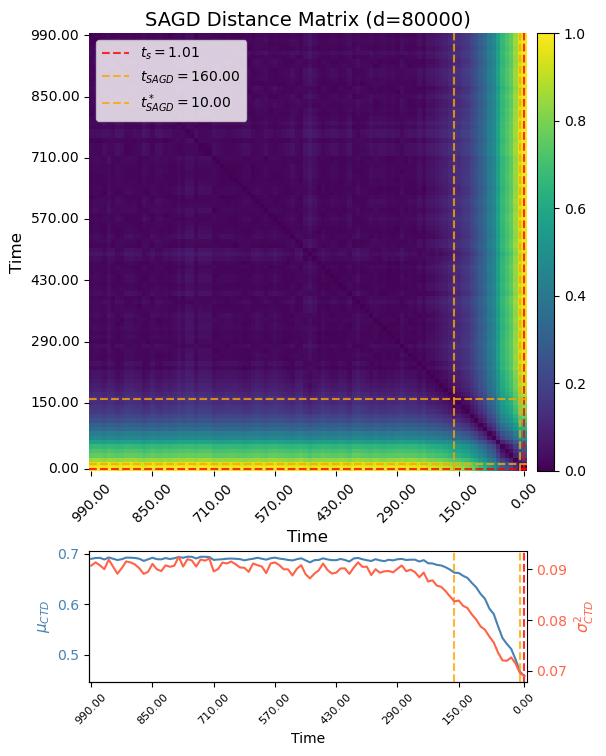

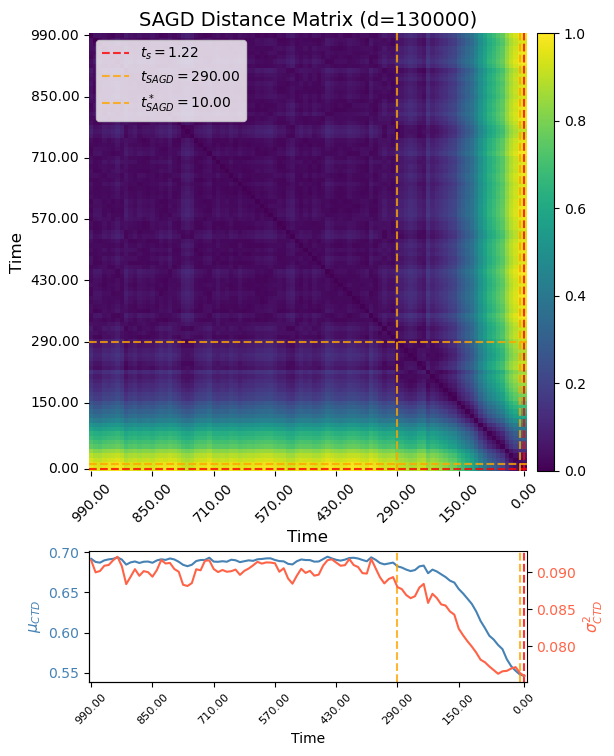

In [4]:
plot_sagd_heatmap_row_mnist(exp_path=Path("../Saves/History/MNIST_5000_newUnet/"), 
                            steps=[80000])
plot_sagd_heatmap_row_mnist(exp_path=Path("../Saves/History/MNIST_15000_3class_newUnet/"), 
                            steps=[130000])